# Tutorial: Learning for OU process with Neural SDE

In this tutorial, we will walk through the process of setting up and testing Neural ODE, Neural CDE, and different formulation of Neural SDE models for a regression task using simulation data generated from an Ornstein-Uhlenbeck (OU) process.

### Step 1: Generate OU Process Data

The Ornstein-Uhlenbeck (OU) process is a type of stochastic differential equation (SDE) commonly used in financial mathematics and other fields. The OU process is defined by the following SDE:

$$ dX_t = \theta (\mu - X_t) \, dt + \sigma \, dW_t $$

where:
- $\theta$ is the mean reversion rate,
- $\mu$ is the long-term mean,
- $\sigma$ is the volatility,
- $W_t$ is a Wiener process (or Brownian motion).

Let's generate data using the OU process:

$\mu X_t - X_t^3$

In [31]:
import os
import random
from typing import Any, Tuple, List
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchcde
import torchsde
from torch.utils.data import Dataset, DataLoader

def seed_everything(seed: Any) -> None:
    """
    Set random seeds for `os`, `numpy`, `random` and `torch`
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.random.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [32]:

def ou_process(T: float, N: int, theta: float, mu: float, sigma: float, X0: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simulate the 1D Ornstein-Uhlenbeck process.
    
    dX = theta * (mu - X) * dt + sigma * dW

    Parameters:
        T (float): Total time.
        N (int): Number of time steps.
        theta (float): Rate of mean reversion.
        mu (float): Long-term mean.
        sigma (float): Volatility.
        X0 (float): Initial value.

    Returns:
        np.ndarray: Simulated values of the OU process.
    """
    
    dt = T / N
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = X0

    for i in range(1, N):
        dW = np.random.normal(0, np.sqrt(dt))
        X[i] = X[i-1] + theta * (mu - X[i-1]) * dt + sigma * dW

    return t, X

def generate_data(num_samples: int, T: float, N: int, theta: float, mu: float, sigma: float, X0: float):
    """
    Generate multiple samples of the OU process and compute CDE coefficients.
    
    Parameters
        `num_samples` (int): Number of samples to generate.
        `T` (float): Total time.
        `N` (int): Number of time steps.
        `theta` (float): Rate of mean reversion.
        `mu` (float): Long-term mean.
        `sigma` (float): Volatility.
        `X0` (float): Initial value.
    
    Returns
        - `Tuple[total_data, coeffs, times]`
        - `total_data` (torch.Tensor): Tensor of shape [Batch size, Length, Dimension].
        - `coeffs` (torch.Tensor): Coefficients for CDE interpolation.
        - `times` (torch.Tensor): Time tensor.
    """
    data_list = []
    for _ in range(num_samples):
        t, X = ou_process(T, N, theta, mu, sigma, X0)
        data_list.append([t, X])

    total_data = torch.Tensor(np.array(data_list))  # [Batch size, Dimension, Length]
    total_data = total_data.permute(0, 2, 1)  # [Batch size, Length, Dimension]

    max_len = total_data.shape[1]
    times = torch.linspace(0, 1, max_len)
    
    # compute coefficients of cubic Hermite spline interpolation
    # as descrete sequences are treated as continuous
    coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(total_data, times)

    return total_data, coeffs, times

class OU_Dataset(Dataset):
    def __init__(self, data, coeffs):
        self.data = data
        self.coeffs = coeffs

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            self.data[idx, ...],
            self.coeffs[idx, ...],
        )

def split_data(data, coeffs, train_ratio=0.8):
    total_size = len(data)
    train_size = int(total_size * train_ratio)

    train_idx = np.random.choice(range(total_size), train_size, replace=False)
    test_idx = np.array([i for i in range(total_size) if i not in train_idx])

    train_data = data[train_idx, ...]
    test_data = data[test_idx, ...]
    train_coeffs = coeffs[train_idx, ...]
    test_coeffs = coeffs[test_idx, ...]

    return train_data, train_coeffs, test_data, test_coeffs

def create_data_loaders(train_data, train_coeffs, test_data, test_coeffs, batch_size=16):
    train_dataset = OU_Dataset(train_data, train_coeffs)
    test_dataset = OU_Dataset(test_data, test_coeffs)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [72]:
# Parameters
config = {
    'num_samples': 2000,
    'T': 20.0,
    'N': 50,
    'theta': 0.2,
    'mu': 0.0,
    'sigma': 0.1,
    'X0': 1.0,
    'train_ratio': 0.8,
    'batch_size': 64,
    'seed': 42,
}

# Ensure reproducibility
seed_everything(config['seed'])

# Generate data
total_data, coeffs, times = generate_data(config['num_samples'], config['T'], config['N'], config['theta'], config['mu'], config['sigma'], config['X0'])

print(total_data.shape, coeffs.shape, times.shape)

torch.Size([2000, 50, 2]) torch.Size([2000, 49, 8]) torch.Size([50])


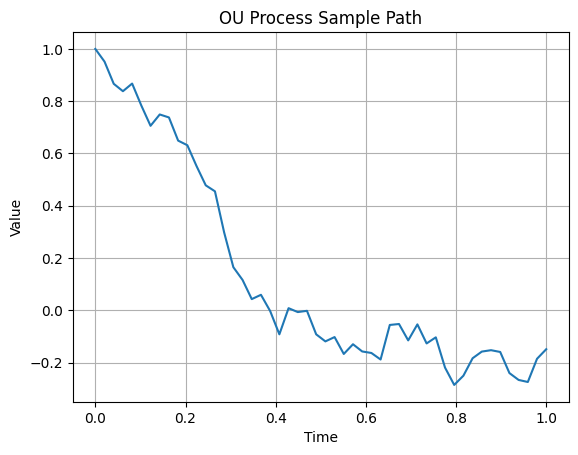

In [73]:
# Split data
train_data, train_coeffs, test_data, test_coeffs = split_data(total_data, coeffs, config['train_ratio'])

# Create data loaders
train_loader, test_loader = create_data_loaders(train_data, train_coeffs, test_data, test_coeffs, config['batch_size'])

# Plot the first sample for verification
plt.plot(times.numpy(), total_data[0, :, 1].numpy())
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('OU Process Sample Path')
plt.grid('on')
plt.show()

### Step 2: Define model

We can define Neural SDE as follows:

$$
dz(t) = f(t, z(t); \theta_f) \, dt + g(t, z(t); \theta_g) \, dW_t
$$

Please refer original paper for the details: [https://arxiv.org/pdf/2402.14989](https://arxiv.org/pdf/2402.14989)

In [74]:
class LipSwish(nn.Module):
    def forward(self, x):
        return 0.909 * torch.nn.functional.silu(x)

class MLP(nn.Module):
    def __init__(self, in_size, out_size, hidden_dim, num_layers, tanh=False, activation='lipswish'):
        super().__init__()

        if activation == 'lipswish':
            activation_fn = LipSwish()
        else:
            activation_fn = nn.ReLU()

        model = [nn.Linear(in_size, hidden_dim), activation_fn]
        for _ in range(num_layers - 1):
            model.append(nn.Linear(hidden_dim, hidden_dim))
            model.append(activation_fn)
        model.append(nn.Linear(hidden_dim, out_size))
        if tanh:
            model.append(nn.Tanh())
        self._model = nn.Sequential(*model)

    def forward(self, x):
        return self._model(x)

class NeuralSDEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim, hidden_hidden_dim, num_layers, activation='lipswish'):
        super(NeuralSDEFunc, self).__init__()
        self.sde_type = "ito"
        self.noise_type = "diagonal" # or "scalar"

        self.linear_in = nn.Linear(hidden_dim + 1, hidden_dim)
        self.f_net = MLP(hidden_dim, hidden_dim, hidden_hidden_dim, num_layers, activation=activation)
        self.linear_out = nn.Linear(hidden_dim, hidden_dim)
        self.noise_in = nn.Linear(hidden_dim + 1, hidden_dim)
        self.g_net = MLP(hidden_dim, hidden_dim, hidden_hidden_dim, num_layers, activation=activation)

    def set_X(self, coeffs, times):
        self.coeffs = coeffs
        self.times = times
        self.X = torchcde.CubicSpline(self.coeffs, self.times)
    
    def f(self, t, y):
        if t.dim() == 0:
            t = torch.full_like(y[:, 0], fill_value=t).unsqueeze(-1)
        # yy = self.linear_in(torch.cat((torch.sin(t), torch.cos(t), y), dim=-1))
        yy = self.linear_in(torch.cat((t, y), dim=-1))
        return self.f_net(yy)

    def g(self, t, y):
        if t.dim() == 0:
            t = torch.full_like(y[:, 0], fill_value=t).unsqueeze(-1)
        # yy = self.noise_in(torch.cat((torch.sin(t), torch.cos(t), y), dim=-1))
        yy = self.noise_in(torch.cat((t, y), dim=-1))
        return self.g_net(yy)

class NDE_model(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, activation='lipswish', vector_field: Any=None):
        super(NDE_model, self).__init__()
        self.func:NeuralSDEFunc = vector_field(input_dim, hidden_dim, hidden_dim, num_layers, activation=activation)
        self.initial = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, output_dim)

    def forward(self, coeffs, times):
        # control module
        self.func.set_X(coeffs, times)

        y0 = self.func.X.evaluate(times[0])
        y0 = self.initial(y0)

        z = torchsde.sdeint(sde=self.func,
                            y0=y0,
                            ts=times,
                            dt=0.05,
                            method='euler')
        # print("int: ", z.shape)
        z = z.permute(1,0,2)
        # print("Permuted: ", z.shape, end="\n\n")
        # print("Decoded: ", self.decoder(z).shape, end="\n\n")
        return self.decoder(z)

In [75]:
input_dim = 2
output_dim = 1
hidden_dim = 32
num_layers = 1

model = NDE_model(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers, vector_field=NeuralSDEFunc).to(device)

In [76]:
num_epochs = 100
lr = 1e-3

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()

Test Loss: 0.10882563676152911


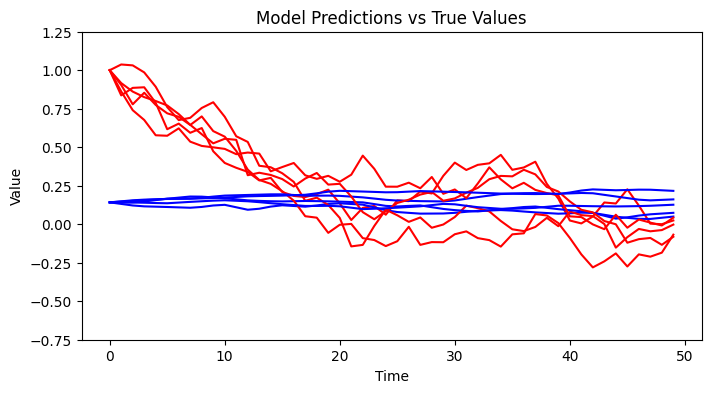

In [77]:
model.eval()
total_loss = 0
all_preds = []
all_trues = []
with torch.no_grad():
    for batch in test_loader:
        coeffs = batch[1].to(device)
        times = torch.linspace(0, 1, batch[0].shape[1]).to(device)

        true = batch[0][:,:,1].to(device)
        pred = model(coeffs, times).squeeze(-1)
        loss = criterion(pred, true)
        total_loss += loss.item()

        all_preds.append(pred.cpu())
        all_trues.append(true.cpu())

avg_loss = total_loss / len(test_loader)
print(f'Test Loss: {avg_loss}')

all_preds = torch.cat(all_preds, dim=0)
all_trues = torch.cat(all_trues, dim=0)

##
num_samples = 5

plt.figure(figsize=(8, 4))
for i in range(num_samples):
    plt.plot(all_trues[i].numpy(), color='r')
    plt.plot(all_preds[i].numpy(), color='b')
plt.xlabel('Time')
plt.ylabel('Value')
plt.ylim(-0.75,1.25)
plt.title('Model Predictions vs True Values')
plt.show()

In [82]:
class SoftHistogramKL(nn.Module):
    def __init__(self, n_bins=10, sigma=0.1):
        super().__init__()
        self.n_bins = n_bins
        self.sigma = sigma  # 软分箱的带宽，越大越平滑
        self.kl = nn.KLDivLoss(reduction='batchmean')
        
    def forward(self, pred, true, ks):
        """
        pred/true: [batch_size, seq_len, 1]
        k: 时间步索引
        """
        
        loss = torch.tensor(0.0, requires_grad=True)
        
        for k in ks:
            pred_k = pred[:, k]  # [batch_size]
            true_k = true[:, k]  # [batch_size]
            
            # 动态确定分箱范围（覆盖 pred 和 true 的范围）
            vmin = min(pred_k.min().item(), true_k.min().item()) - 0.1
            vmax = max(pred_k.max().item(), true_k.max().item()) + 0.1
            bins = torch.linspace(vmin, vmax, self.n_bins, device=pred.device)
            
            # 软分箱（可微分）：使用高斯核计算每个样本属于每个 bin 的权重
            # pred_k: [batch_size] -> bins: [n_bins]
            dist_p = torch.abs(pred_k.unsqueeze(1) - bins.unsqueeze(0))  # [batch, n_bins]
            dist_t = torch.abs(true_k.unsqueeze(1) - bins.unsqueeze(0))
            
            # 高斯软分箱
            weights_p = torch.exp(-dist_p.pow(2) / (2 * self.sigma**2))
            weights_t = torch.exp(-dist_t.pow(2) / (2 * self.sigma**2))
            
            # 归一化为概率分布（在 batch 维度求和，得到每个 bin 的频率）
            hist_p = weights_p.sum(dim=0)  # [n_bins]
            hist_t = weights_t.sum(dim=0)  # [n_bins]
            
            # 加平滑避免 log(0)，并归一化
            prob_p = (hist_p + 1e-6) / (hist_p.sum() + 1e-6 * self.n_bins)
            prob_t = (hist_t + 1e-6) / (hist_t.sum() + 1e-6 * self.n_bins)
            
            # 严格按照 KLDivLoss 文档：input 必须是 log_prob，target 是 prob
            # reduction='batchmean' 此时等同于对 n_bins 个 bins 的平均
            loss = loss + self.kl(prob_p.log(), prob_t) * max(1, k**0.5)
        return loss / len(ks)


In [79]:
def pathwise_kl_loss(pred_trajectories, true_trajectories, batch_size):
    """
    pred: [n_samples, batch, T, 1] —— 多条预测路径
    true: [batch, T, 1] —— 真实路径（或 true 也有多条）
    """
    # 将整条路径展平为向量 [n_samples, batch, T]
    pred_flat = pred_trajectories.squeeze(-1)  # [n_samples, batch, T]
    
    # 计算每个 batch 元素的经验分布
    # 使用 Energy Distance 或 MMD，无需假设高斯性
    def energy_distance(X, Y):
        # X: [n, d], Y: [m, d] 都是路径
        n, m = X.size(0), Y.size(0)
        XX = torch.pdist(X, p=2).pow(2).mean()
        YY = torch.pdist(Y, p=2).pow(2).mean()
        XY = torch.cdist(X, Y, p=2).pow(2).mean()
        return 2*XY - XX - YY
    
    total_ed = 0
    for b in range(batch_size):
        total_ed += energy_distance(pred_flat[:, b], true_trajectories[b:b+1, :])
    
    return total_ed / batch_size

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:02<04:52,  2.96s/it]

  2%|▏         | 2/100 [00:05<04:36,  2.82s/it]

  3%|▎         | 3/100 [00:08<04:29,  2.78s/it]

  4%|▍         | 4/100 [00:11<04:29,  2.81s/it]

Epoch 5, Loss: 0.04119951382279396
Test Loss: 0.0631936714053154


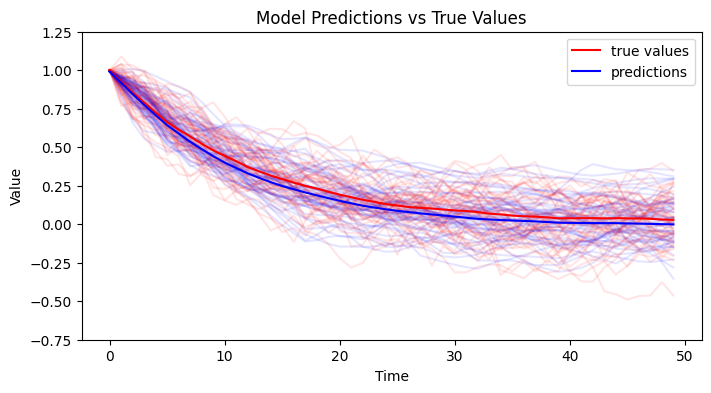

  5%|▌         | 5/100 [00:14<04:51,  3.07s/it]

  6%|▌         | 6/100 [00:17<04:38,  2.96s/it]

  7%|▋         | 7/100 [00:20<04:31,  2.92s/it]

  8%|▊         | 8/100 [00:23<04:22,  2.86s/it]

  9%|▉         | 9/100 [00:25<04:16,  2.82s/it]

Epoch 10, Loss: 0.03799393475055694
Test Loss: 0.05575544546757426


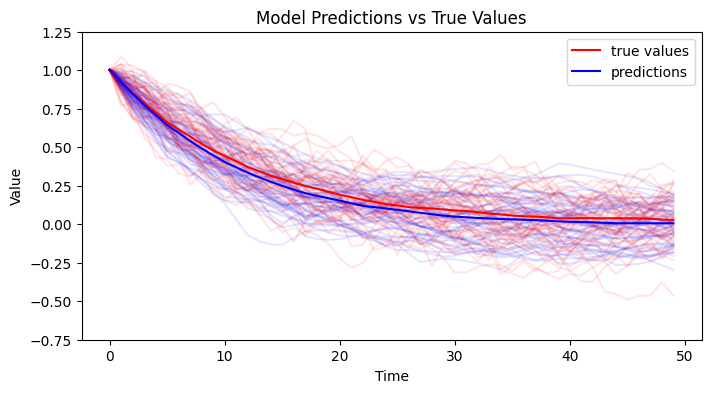

 10%|█         | 10/100 [00:29<04:32,  3.03s/it]

 11%|█         | 11/100 [00:32<04:21,  2.94s/it]

 12%|█▏        | 12/100 [00:34<04:12,  2.87s/it]

 13%|█▎        | 13/100 [00:37<04:06,  2.84s/it]

 14%|█▍        | 14/100 [00:41<04:21,  3.04s/it]

Epoch 15, Loss: 0.03554578572511673
Test Loss: 0.05681341992957251


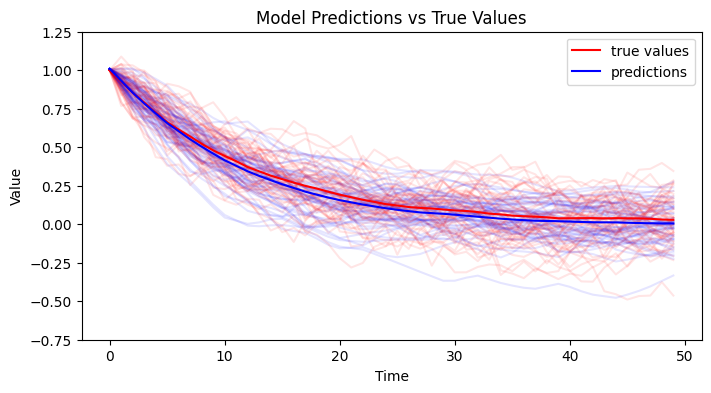

 15%|█▌        | 15/100 [00:44<04:36,  3.25s/it]

 16%|█▌        | 16/100 [00:47<04:25,  3.17s/it]

 17%|█▋        | 17/100 [00:50<04:15,  3.08s/it]

 18%|█▊        | 18/100 [00:53<04:07,  3.02s/it]

 19%|█▉        | 19/100 [00:56<04:01,  2.98s/it]

Epoch 20, Loss: 0.034053839221596716
Test Loss: 0.06007789501122066


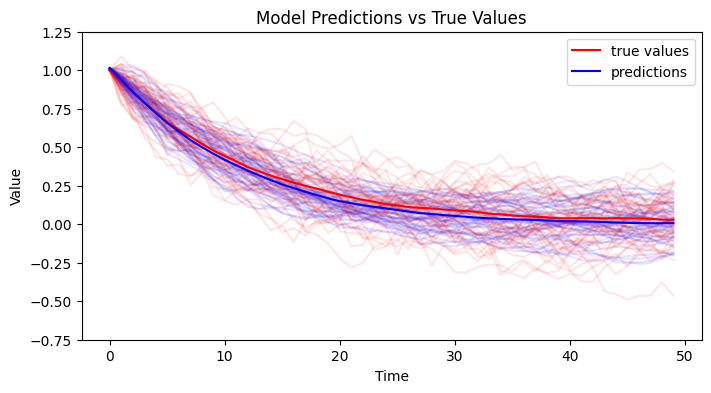

 20%|██        | 20/100 [01:00<04:18,  3.23s/it]

 21%|██        | 21/100 [01:03<04:06,  3.12s/it]

 22%|██▏       | 22/100 [01:05<03:55,  3.02s/it]

 23%|██▎       | 23/100 [01:08<03:54,  3.05s/it]

 24%|██▍       | 24/100 [01:11<03:47,  2.99s/it]

Epoch 25, Loss: 0.032630376368761066
Test Loss: 0.05880099002804075


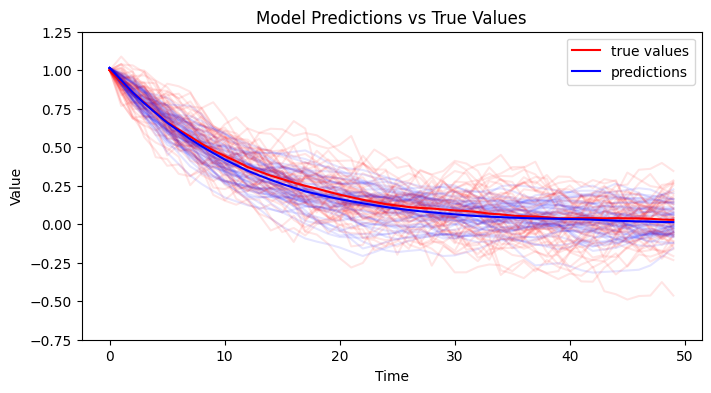

 25%|██▌       | 25/100 [01:15<03:57,  3.16s/it]

 26%|██▌       | 26/100 [01:18<03:43,  3.02s/it]

 27%|██▋       | 27/100 [01:20<03:32,  2.91s/it]

 28%|██▊       | 28/100 [01:23<03:22,  2.81s/it]

 29%|██▉       | 29/100 [01:26<03:17,  2.78s/it]

Epoch 30, Loss: 0.031694547981023787
Test Loss: 0.070662188742842


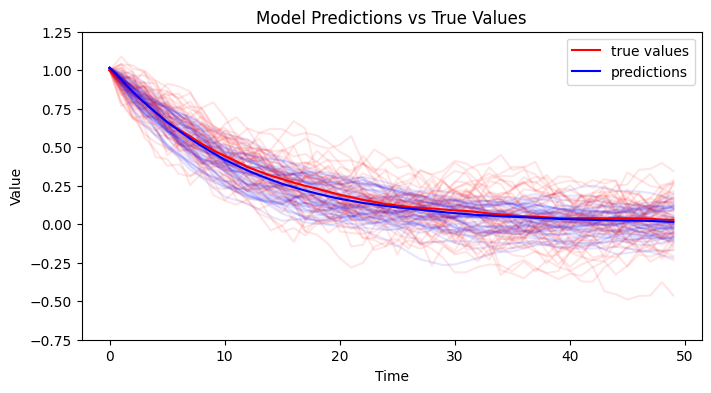

 30%|███       | 30/100 [01:29<03:30,  3.00s/it]

 31%|███       | 31/100 [01:32<03:22,  2.94s/it]

 32%|███▏      | 32/100 [01:35<03:16,  2.89s/it]

 33%|███▎      | 33/100 [01:37<03:08,  2.82s/it]

 34%|███▍      | 34/100 [01:40<03:04,  2.80s/it]

Epoch 35, Loss: 0.0299935057759285
Test Loss: 0.06741535823260035


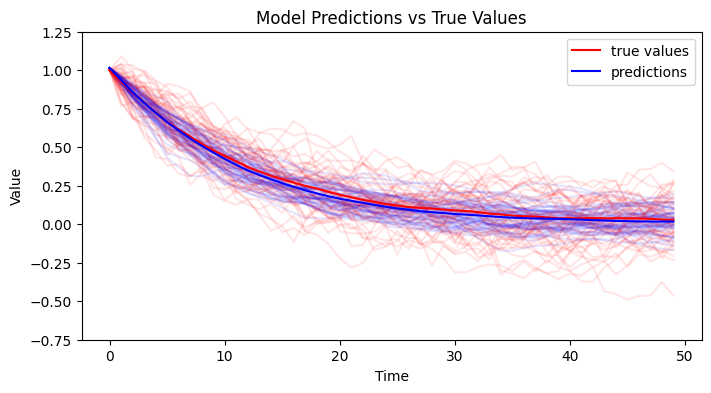

 35%|███▌      | 35/100 [01:43<03:14,  2.99s/it]

 36%|███▌      | 36/100 [01:46<03:07,  2.92s/it]

 37%|███▋      | 37/100 [01:49<03:01,  2.88s/it]

 38%|███▊      | 38/100 [01:52<02:58,  2.87s/it]

 39%|███▉      | 39/100 [01:55<02:53,  2.85s/it]

Epoch 40, Loss: 0.028787756115198137
Test Loss: 0.08084242099097796


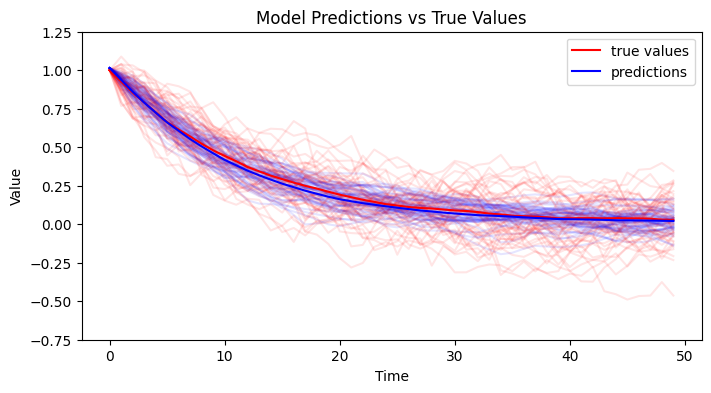

 40%|████      | 40/100 [01:59<03:08,  3.15s/it]

 41%|████      | 41/100 [02:02<03:03,  3.10s/it]

 42%|████▏     | 42/100 [02:04<02:56,  3.04s/it]

 43%|████▎     | 43/100 [02:07<02:47,  2.95s/it]

 44%|████▍     | 44/100 [02:10<02:43,  2.91s/it]

Epoch 45, Loss: 0.02820510670542717
Test Loss: 0.08344177156686783


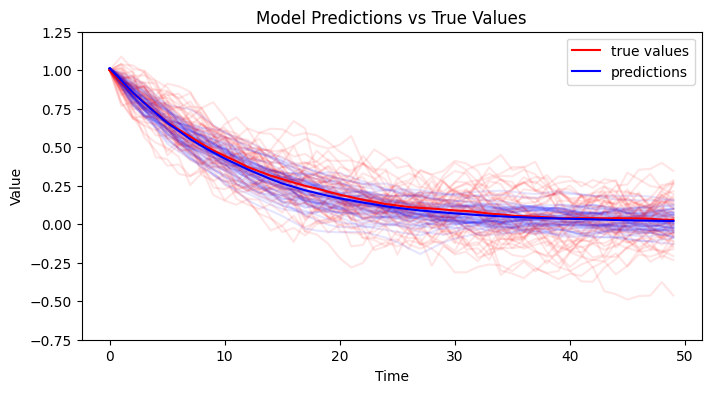

 45%|████▌     | 45/100 [02:13<02:50,  3.09s/it]

 46%|████▌     | 46/100 [02:16<02:44,  3.04s/it]

 47%|████▋     | 47/100 [02:19<02:39,  3.02s/it]

 48%|████▊     | 48/100 [02:22<02:32,  2.93s/it]

 49%|████▉     | 49/100 [02:25<02:24,  2.84s/it]

Epoch 50, Loss: 0.027168961465358733
Test Loss: 0.0837540328502655


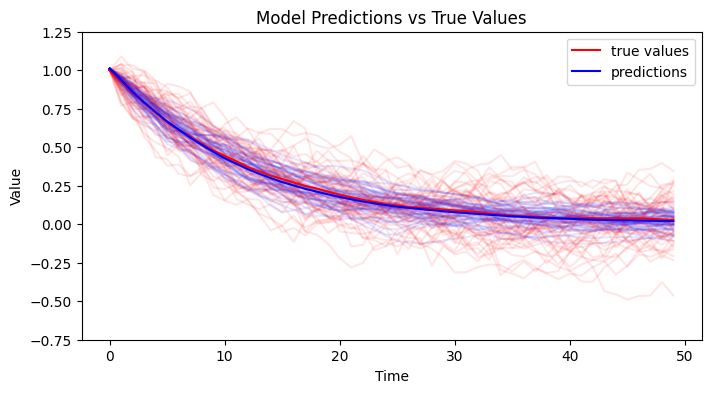

 50%|█████     | 50/100 [02:28<02:29,  2.99s/it]

 51%|█████     | 51/100 [02:31<02:22,  2.92s/it]

 52%|█████▏    | 52/100 [02:33<02:14,  2.80s/it]

 53%|█████▎    | 53/100 [02:36<02:08,  2.72s/it]

 54%|█████▍    | 54/100 [02:38<02:03,  2.69s/it]

Epoch 55, Loss: 0.026602894365787506
Test Loss: 0.10103360137769155


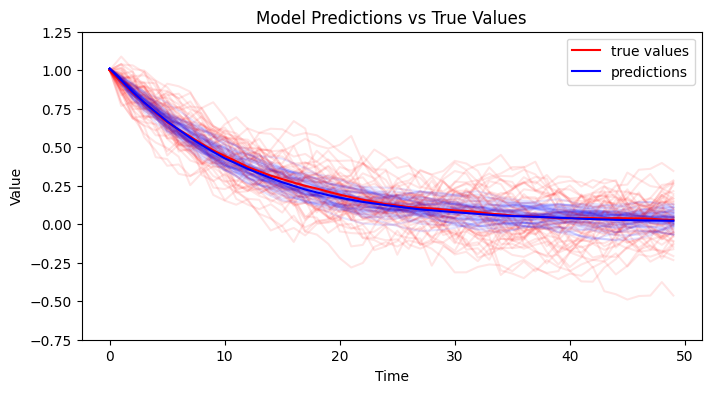

 55%|█████▌    | 55/100 [02:42<02:07,  2.84s/it]

 56%|█████▌    | 56/100 [02:44<02:01,  2.77s/it]

 57%|█████▋    | 57/100 [02:47<01:56,  2.71s/it]

 58%|█████▊    | 58/100 [02:49<01:51,  2.67s/it]

 59%|█████▉    | 59/100 [02:52<01:46,  2.60s/it]

Epoch 60, Loss: 0.026028867661952972
Test Loss: 0.10901112428733281


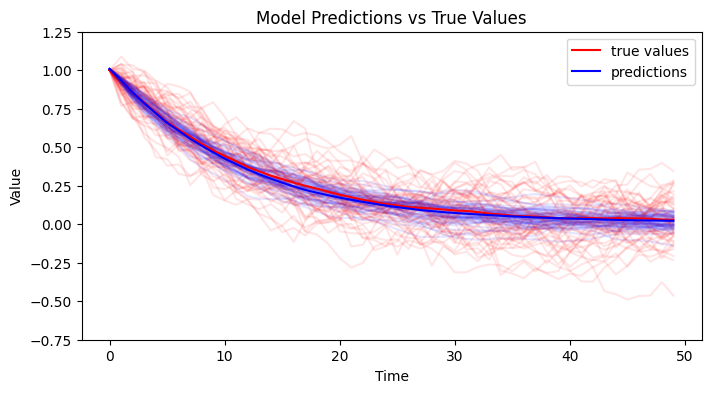

 60%|██████    | 60/100 [02:55<01:51,  2.79s/it]

 61%|██████    | 61/100 [02:58<01:47,  2.76s/it]

 62%|██████▏   | 62/100 [03:00<01:43,  2.71s/it]

 63%|██████▎   | 63/100 [03:03<01:38,  2.65s/it]

 64%|██████▍   | 64/100 [03:05<01:34,  2.62s/it]

Epoch 65, Loss: 0.02495194546878338
Test Loss: 0.12105504529816764


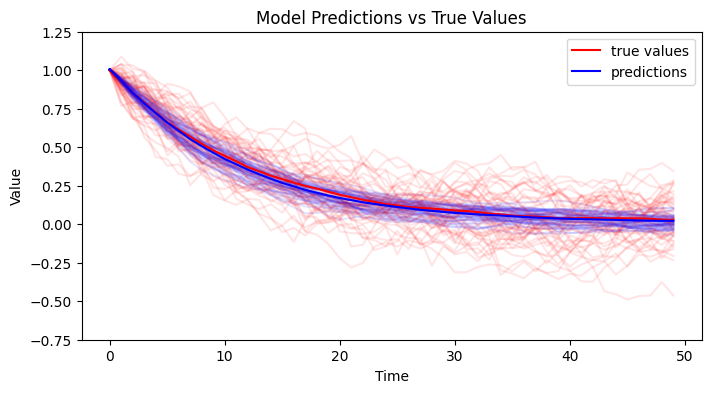

 65%|██████▌   | 65/100 [03:09<01:37,  2.79s/it]

 66%|██████▌   | 66/100 [03:11<01:32,  2.72s/it]

 67%|██████▋   | 67/100 [03:14<01:27,  2.65s/it]

 68%|██████▊   | 68/100 [03:16<01:24,  2.65s/it]

 69%|██████▉   | 69/100 [03:19<01:21,  2.63s/it]

Epoch 70, Loss: 0.024444509521126746
Test Loss: 0.131902100784438


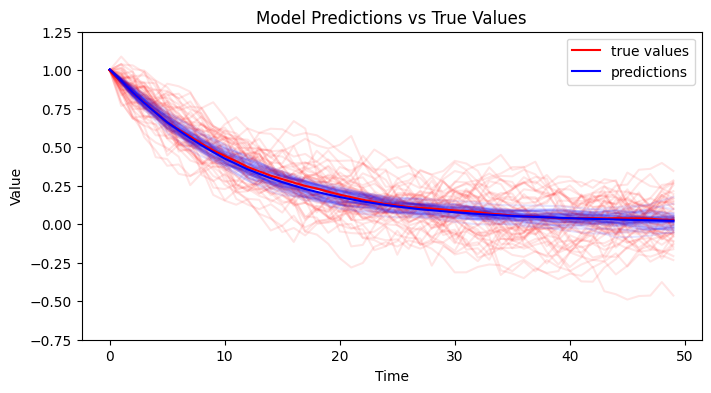

 70%|███████   | 70/100 [03:22<01:27,  2.91s/it]

 71%|███████   | 71/100 [03:25<01:21,  2.83s/it]

 72%|███████▏  | 72/100 [03:28<01:17,  2.76s/it]

 73%|███████▎  | 73/100 [03:31<01:16,  2.82s/it]

 74%|███████▍  | 74/100 [03:33<01:11,  2.76s/it]

Epoch 75, Loss: 0.023903397396206855
Test Loss: 0.14201101660728455


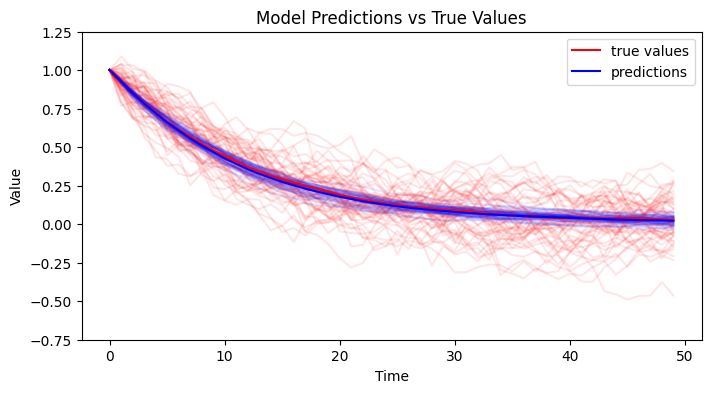

 75%|███████▌  | 75/100 [03:36<01:11,  2.86s/it]

 76%|███████▌  | 76/100 [03:40<01:12,  3.01s/it]

 77%|███████▋  | 77/100 [03:43<01:08,  2.99s/it]

 78%|███████▊  | 78/100 [03:45<01:03,  2.88s/it]

 79%|███████▉  | 79/100 [03:48<01:00,  2.90s/it]

Epoch 80, Loss: 0.02358363077044487
Test Loss: 0.14673670274870737


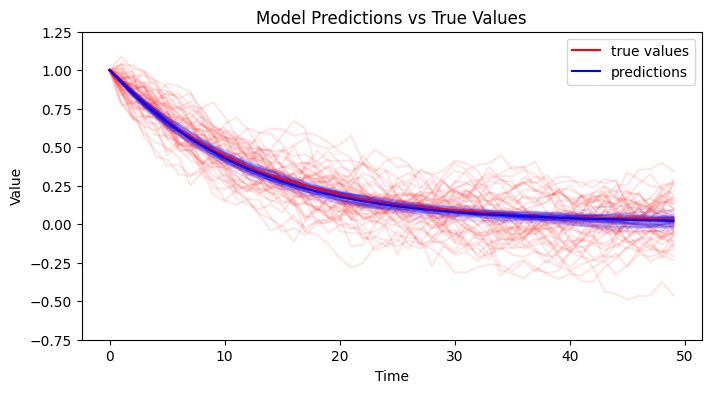

 80%|████████  | 80/100 [03:52<01:02,  3.10s/it]

 81%|████████  | 81/100 [03:55<00:58,  3.07s/it]

 82%|████████▏ | 82/100 [03:58<00:54,  3.01s/it]

 83%|████████▎ | 83/100 [04:00<00:50,  2.95s/it]

 84%|████████▍ | 84/100 [04:03<00:46,  2.92s/it]

Epoch 85, Loss: 0.023586678504943847
Test Loss: 0.15308550000190735


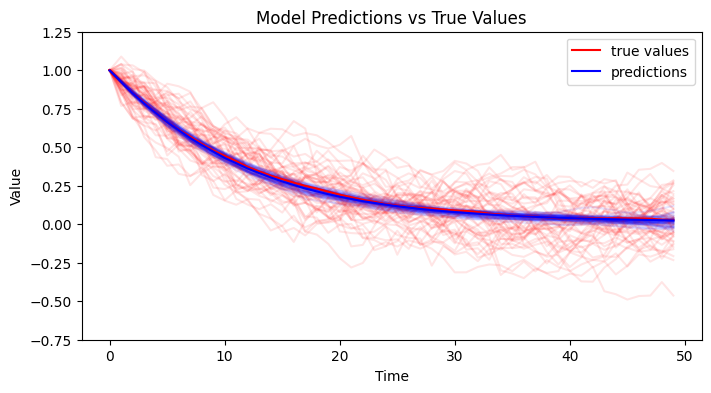

 85%|████████▌ | 85/100 [04:07<00:46,  3.10s/it]

 86%|████████▌ | 86/100 [04:10<00:42,  3.04s/it]

 87%|████████▋ | 87/100 [04:13<00:38,  2.96s/it]

 88%|████████▊ | 88/100 [04:15<00:34,  2.91s/it]

 89%|████████▉ | 89/100 [04:18<00:31,  2.86s/it]

Epoch 90, Loss: 0.02347214914858341
Test Loss: 0.15655454780374253


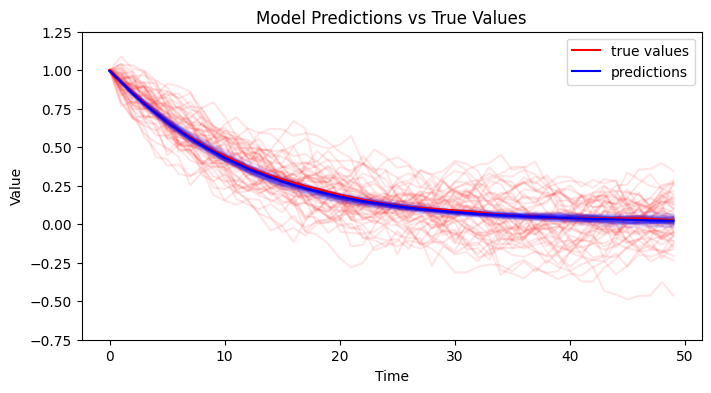

 90%|█████████ | 90/100 [04:22<00:30,  3.04s/it]

 91%|█████████ | 91/100 [04:24<00:26,  2.99s/it]

 92%|█████████▏| 92/100 [04:27<00:23,  2.91s/it]

 93%|█████████▎| 93/100 [04:30<00:20,  2.87s/it]

 94%|█████████▍| 94/100 [04:33<00:17,  2.86s/it]

Epoch 95, Loss: 0.023359607234597207
Test Loss: 0.15824689183916366


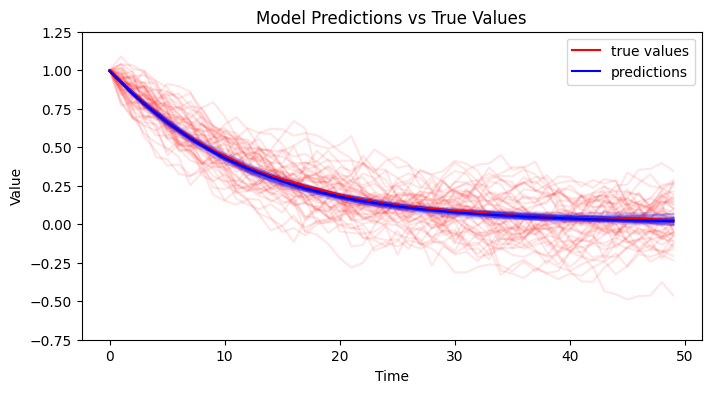

 95%|█████████▌| 95/100 [04:36<00:15,  3.11s/it]

 96%|█████████▌| 96/100 [04:39<00:12,  3.07s/it]

 97%|█████████▋| 97/100 [04:42<00:08,  2.93s/it]

 98%|█████████▊| 98/100 [04:45<00:05,  2.83s/it]

 99%|█████████▉| 99/100 [04:48<00:02,  2.86s/it]

Epoch 100, Loss: 0.023375785797834395
Test Loss: 0.1594204923936299


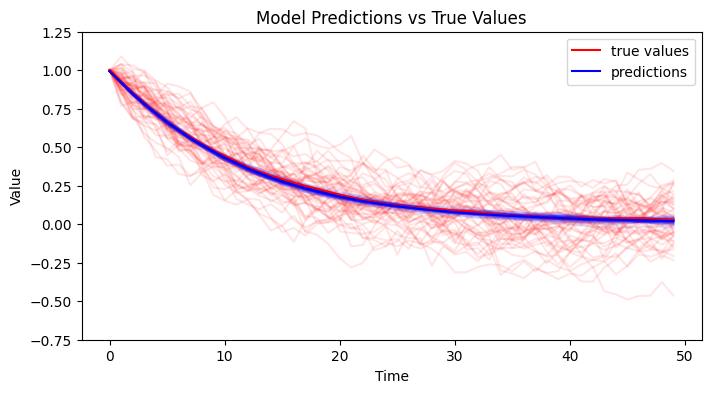

100%|██████████| 100/100 [04:51<00:00,  2.91s/it]


In [89]:
from tqdm import tqdm

kl_div = SoftHistogramKL()
num_samples = 5

for epoch in tqdm(range(1,num_epochs+1)):
    model.train()
    total_loss = 0
    for batch in train_loader:
        coeffs = batch[1].to(device)
        times = torch.linspace(0, 1, batch[0].shape[1]).to(device)

        optimizer.zero_grad()
        true = batch[0][:,:,1].to(device)
        pred = model(coeffs, times).squeeze(-1)
        # print(pred.shape, true.shape)
        loss_mse = criterion(pred, true) 
        loss_kl = kl_div(pred, true, random.choices(list(range(pred.shape[1])), k=int(max(pred.shape[1]**0.5, 2))))
        loss = loss_mse + 0 * loss_kl
        print(f"{loss_mse=:.4f}, {loss_kl=:.4f}", end='\r')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 100)
        optimizer.step()

        total_loss += loss.item()

    if epoch % 5 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch}, Loss: {avg_loss}')

        ##
        model.eval()
        total_loss = 0
        all_preds = []
        all_trues = []
        with torch.no_grad():
            for batch in test_loader:
                coeffs = batch[1].to(device)
                times = torch.linspace(0, 1, batch[0].shape[1]).to(device)
        
                true = batch[0][:,:,1].to(device)
                # print(coeffs.shape, times.shape)
                pred = model(coeffs, times).squeeze(-1)
                
                loss_mse = criterion(pred, true) 
                loss_kl = kl_div(pred, true, [0, 5, 7, 10, 13, 15])
                loss = loss_mse + loss_kl
                total_loss += loss.item()
        
                all_preds.append(pred.cpu())
                all_trues.append(true.cpu())
        
        avg_loss = total_loss / len(test_loader)
        print(f'Test Loss: {avg_loss}')
        
        all_preds = torch.cat(all_preds, dim=0)
        all_trues = torch.cat(all_trues, dim=0)
    
        ##      
        plt.figure(figsize=(8, 4))
        for i in range(num_samples * 10):
            plt.plot(all_trues[i].numpy(), color='r', alpha=0.1)
            plt.plot(all_preds[i].numpy(), color='b', alpha=0.1)
        
        plt.plot(all_trues.mean(0).numpy(), color='r', label="true values")
        plt.plot(all_preds.mean(0).numpy(), color='b', label="predictions")
        
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.ylim(-0.75,1.25)
        
        plt.title('Model Predictions vs True Values')
        plt.show()

In [ ]:
def kl_timeslice_gaussian(pred, true, k):
    """
    pred: [n_samples, seq_len] - 生成轨迹（同一初始条件，不同布朗运动）
    true: [n_samples, seq_len] - 真实轨迹（同一初始条件，不同实现）
    k: 时间步索引（竖切位置）
    """
    # 竖切提取时刻 k 的值 [n_samples]
    pred_k = pred[:, k]  
    true_k = true[:, k]
    
    # 计算统计量（无偏估计）
    mu_p, var_p = pred_k.mean(), pred_k.var(unbiased=True)
    mu_t, var_t = true_k.mean(), true_k.var(unbiased=True)
    
    # 数值保护
    var_t = torch.clamp(var_t, min=1e-6)
    var_p = torch.clamp(var_p, min=1e-6)
    
    # KL(N(mean_p, var_p) || N(mean_t, var_t))
    kl = 0.5 * (var_p/var_t + (mu_p - mu_t).pow(2)/var_t - 1 + torch.log(var_t/var_p))
    
    return kl

# 使用
loss_kl = kl_timeslice_gaussian(pred, true, k=20)  # t=0.2 对应索引 20
total_loss = mse_loss + 0.5 * loss_kl  # 调大权重，0.5-2.0 之间尝试

In [65]:
from tqdm import tqdm

kl_div = SoftHistogramKL()
num_samples = 5

for epoch in tqdm(range(1,num_epochs+1)):
    model.train()
    total_loss = 0
    for batch in train_loader:
        coeffs = batch[1].to(device)
        times = torch.linspace(0, 1, batch[0].shape[1]).to(device)

        optimizer.zero_grad()
        true_path = batch[0][:,:,1].to(device)
        pred_path = model(coeffs, times).squeeze(-1)
        # print(pred.shape, true.shape)
        
        print(pred_path.shape, flush=True)
        loss_mse = criterion(pred_path, true_path) 
        loss_kl = pathwise_kl_loss(pred_path, true_path, config['batch_size'])
        loss = loss_mse + loss_kl
        print(f"{loss_mse=:.4f}, {loss_kl=:.4f}", end='\r')
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch}, Loss: {avg_loss}')

        ##
        model.eval()
        total_loss = 0
        all_preds = []
        all_trues = []
        with torch.no_grad():
            for batch in test_loader:
                coeffs = batch[1].to(device)
                times = torch.linspace(0, 1, batch[0].shape[1]).to(device)
        
                true_path = batch[0][:,:,1].to(device)
                # print(coeffs.shape, times.shape)
                pred_path = model(coeffs, times).squeeze(-1)
                
                loss_mse = criterion(pred_path, true_path) 
                loss_kl = pathwise_kl_loss(pred_path, true_path, config['batch_size'])
                loss = loss_mse + loss_kl
                total_loss += loss.item()
        
                all_preds.append(pred.cpu())
                all_trues.append(true.cpu())
        
        avg_loss = total_loss / len(test_loader)
        print(f'Test Loss: {avg_loss}')
        
        all_preds = torch.cat(all_preds, dim=0)
        all_trues = torch.cat(all_trues, dim=0)
    
        ##      
        plt.figure(figsize=(8, 4))
        for i in range(num_samples):
            if i == 0:
                plt.plot(all_trues[i].numpy(), color='r', label="true values")
                plt.plot(all_preds[i].numpy(), color='b', label="predictions")
            else:   
                plt.plot(all_trues[i].numpy(), color='r')
                plt.plot(all_preds[i].numpy(), color='b')
                
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.ylim(-0.75,1.25)
        
        plt.title('Model Predictions vs True Values')
        plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([64, 100])


  0%|          | 0/100 [00:00<?, ?it/s]


RuntimeError: pdist only supports 2D tensors, got: 1D

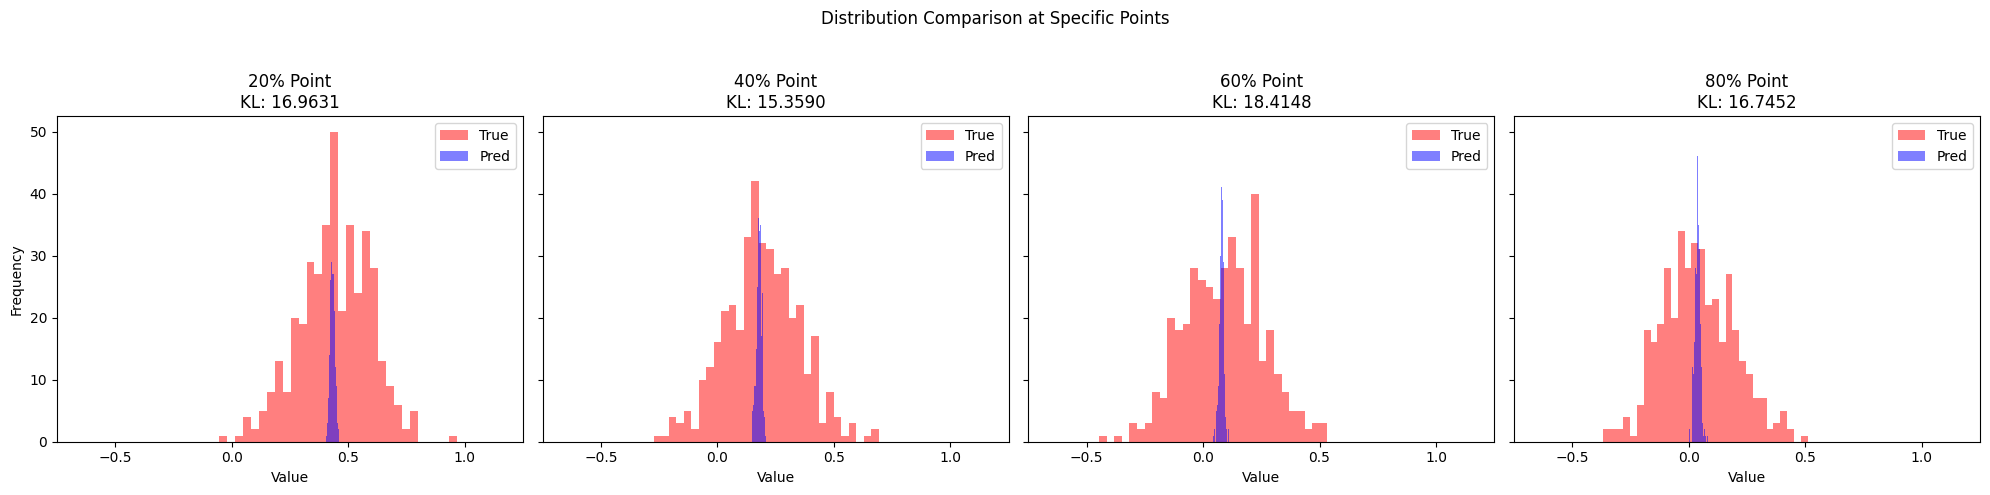

: 

In [ ]:
from scipy.stats import entropy

def calculate_kl_divergence(true_values, pred_values, num_bins=30):
    # Compute histogram for true and predicted values
    hist_true, bin_edges = np.histogram(true_values, bins=num_bins, density=True)
    hist_pred, _ = np.histogram(pred_values, bins=bin_edges, density=True)

    # Avoid division by zero and log(0) issues
    hist_true = np.where(hist_true == 0, 1e-10, hist_true)
    hist_pred = np.where(hist_pred == 0, 1e-10, hist_pred)

    # Calculate KL divergence
    kl_div = entropy(hist_true, hist_pred)
    return kl_div

def calculate_kl_divergence_torch(true_values, pred_values, num_bins=30):
    # Compute histogram for true and predicted values
    hist_true, bin_edges = torch.histogram(true_values, bins=num_bins, density=True)
    hist_pred, _ = torch.histogram(pred_values, bins=bin_edges, density=True)

    # Avoid division by zero and log(0) issues
    hist_true = torch.where(hist_true == 0, 1e-10, hist_true)
    hist_pred = torch.where(hist_pred == 0, 1e-10, hist_pred)

    # Calculate KL divergence
    kl_div = entropy(hist_true, hist_pred)
    return kl_div

def compare_distributions(true_data, pred_data, points, num_bins=30):
    time_points = [int(p * true_data.shape[1]) for p in points]
    
    fig, axes = plt.subplots(1, len(points), figsize=(20, 5), sharey=True)
    
    for ax, point, time_point in zip(axes, points, time_points):
        true_values = true_data[:, time_point].numpy()
        pred_values = pred_data[:, time_point].numpy()
        
        kl_div = calculate_kl_divergence(true_values, pred_values, num_bins)
        
        ax.hist([round(v,5) for v in true_values], bins=num_bins, alpha=0.5, label='True', color='r')
        ax.hist([round(v,5) for v in pred_values], bins=num_bins, alpha=0.5, label='Pred', color='b')
        ax.set_title(f'{int(point * 100)}% Point\nKL: {kl_div:.4f}')
        ax.set_xlabel('Value')
        ax.set_xlim(-0.75,1.25)
        ax.set_xticks([-0.5,0.0,0.5,1.0])
        if ax == axes[0]:
            ax.set_ylabel('Frequency')
        ax.legend()

    plt.suptitle('Distribution Comparison at Specific Points')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

points_to_compare = [0.2, 0.4, 0.6, 0.8]
compare_distributions(all_trues, all_preds, points_to_compare)

In [ ]:
for epoch in range(1,num_epochs+1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        coeffs = batch[1].to(device)
        times = torch.linspace(0, 1, batch[0].shape[1]).to(device)

        optimizer.zero_grad()
        true = batch[0][:,:,1].to(device)
        pred = model(coeffs, times).squeeze(-1)
        loss = criterion(pred, true)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch}, Loss: {avg_loss}')

        ##
        model.eval()
        total_loss = 0
        all_preds = []
        all_trues = []
        with torch.no_grad():
            for batch in test_loader:
                coeffs = batch[1].to(device)
                times = torch.linspace(0, 1, batch[0].shape[1]).to(device)
        
                true = batch[0][:,:,1].to(device)
                pred = model(coeffs, times).squeeze(-1)
                loss = criterion(pred, true) + 
                total_loss += loss.item()
        
                all_preds.append(pred.cpu())
                all_trues.append(true.cpu())
        
        avg_loss = total_loss / len(test_loader)
        print(f'Test Loss: {avg_loss}')
        
        all_preds = torch.cat(all_preds, dim=0)
        all_trues = torch.cat(all_trues, dim=0)
    
        ##      
        plt.figure(figsize=(8, 4))
        for i in range(num_samples):
            plt.plot(all_trues[i].numpy(), color='r', label="true values")
            plt.plot(all_preds[i].numpy(), color='b', label="predictions")
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.ylim(-0.75,1.25)
        plt.title('Model Predictions vs True Values')
        plt.show()

SyntaxError: invalid syntax (2377027412.py, line 33)